>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "nP", "sym": "$K$", "int": True, "pos": 2}
variable_2 = {"name": "nV", "sym": "$N$", "int": True, "pos": 4}
variables = {"variable_1": variable_1, "variable_2": variable_2}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'-'+variable_2["name"])
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [4]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [5]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl['scn'] = var_val
conv_repl.head(3)

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged,scn
408,9,172.161592,41,700.296905,41,True,60000_250
409,63,98.005131,44,533.246557,63,True,60000_250
410,22,121.950281,24,701.024309,24,True,60000_250
411,31,96.403262,44,472.407710,44,True,60000_250
412,55,104.725663,36,724.568004,55,True,60000_250
413,51,107.814800,26,644.554965,51,True,60000_250
414,25,118.060004,16,894.608761,25,True,60000_250
415,46,103.072415,38,611.091319,46,True,60000_250
416,10,146.526048,39,984.771836,39,True,60000_250
417,36,105.986028,39,492.459598,39,True,60000_250


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 7/4 for scenario 15000_1000
Sufficient number of replications: 15/11 for scenario 15000_125
Sufficient number of replications: 5/1 for scenario 15000_1500
Sufficient number of replications: 5/1 for scenario 15000_2000
Sufficient number of replications: 5/3 for scenario 15000_250
Sufficient number of replications: 5/2 for scenario 15000_2500
Sufficient number of replications: 5/4 for scenario 15000_500
Sufficient number of replications: 5/1 for scenario 30000_1000
Sufficient number of replications: 15/13 for scenario 30000_125
Sufficient number of replications: 5/1 for scenario 30000_1500
Sufficient number of replications: 5/1 for scenario 30000_2000
Sufficient number of replications: 7/4 for scenario 30000_250
Sufficient number of replications: 5/1 for scenario 30000_2500
Sufficient number of replications: 5/2 for scenario 30000_500
Sufficient number of replications: 35/13 for scenario 3750_1000
Sufficient number of replications: 35/11 for scenario 37

In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [22]:
eql_scn.sup.head(5)

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time,nP,nV
scenario,,,,,,,,,,,,,,,,,,,,,
15000_1000,1000.0,42.200000,0.0,16.942857,0.0,62.920081,63.158944,62.642934,62.523638,0.473409,...,25.843326,16.500351,9.342975,37.371901,3737.190086,6600.140228,10337.330315,0.641065,15000,1000
15000_125,125.0,8.266667,0.0,5.760000,0.0,76.738564,76.510986,76.252301,78.025161,0.578131,...,44.107445,22.605349,21.502096,86.008382,8600.838249,9042.139711,17642.977960,0.387397,15000,125
15000_1500,1500.0,59.280000,0.0,19.960000,0.0,57.730259,58.516052,57.914794,58.084586,0.435798,...,23.115714,15.183698,7.932016,31.728062,3172.806228,6073.479280,9246.285508,0.678948,15000,1500
15000_2000,2000.0,63.840000,0.0,20.760000,0.0,56.948908,57.666970,56.278860,58.488963,0.429422,...,22.682244,15.152055,7.530189,30.120755,3012.075545,6060.822164,9072.897708,0.684969,15000,2000
15000_250,250.0,14.800000,0.0,8.760000,0.0,72.854917,72.997880,72.581886,74.970694,0.548058,...,37.591754,20.982020,16.609733,66.438934,6643.893391,8392.808056,15036.701447,0.477892,15000,250


In [11]:
eql_scn.plf.head(5)

,plat_profit
15000_1000,491.903132
15000_125,238.856805
15000_1500,535.264320
15000_2000,556.742370
15000_250,327.349110


In [12]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [14]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variables)
eql_scn.dem = add_scn_vals(eql_scn.dem, variables)
eql_scn.plf = add_scn_vals(eql_scn.plf, variables)

In [19]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variables)

C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:204: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:209: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


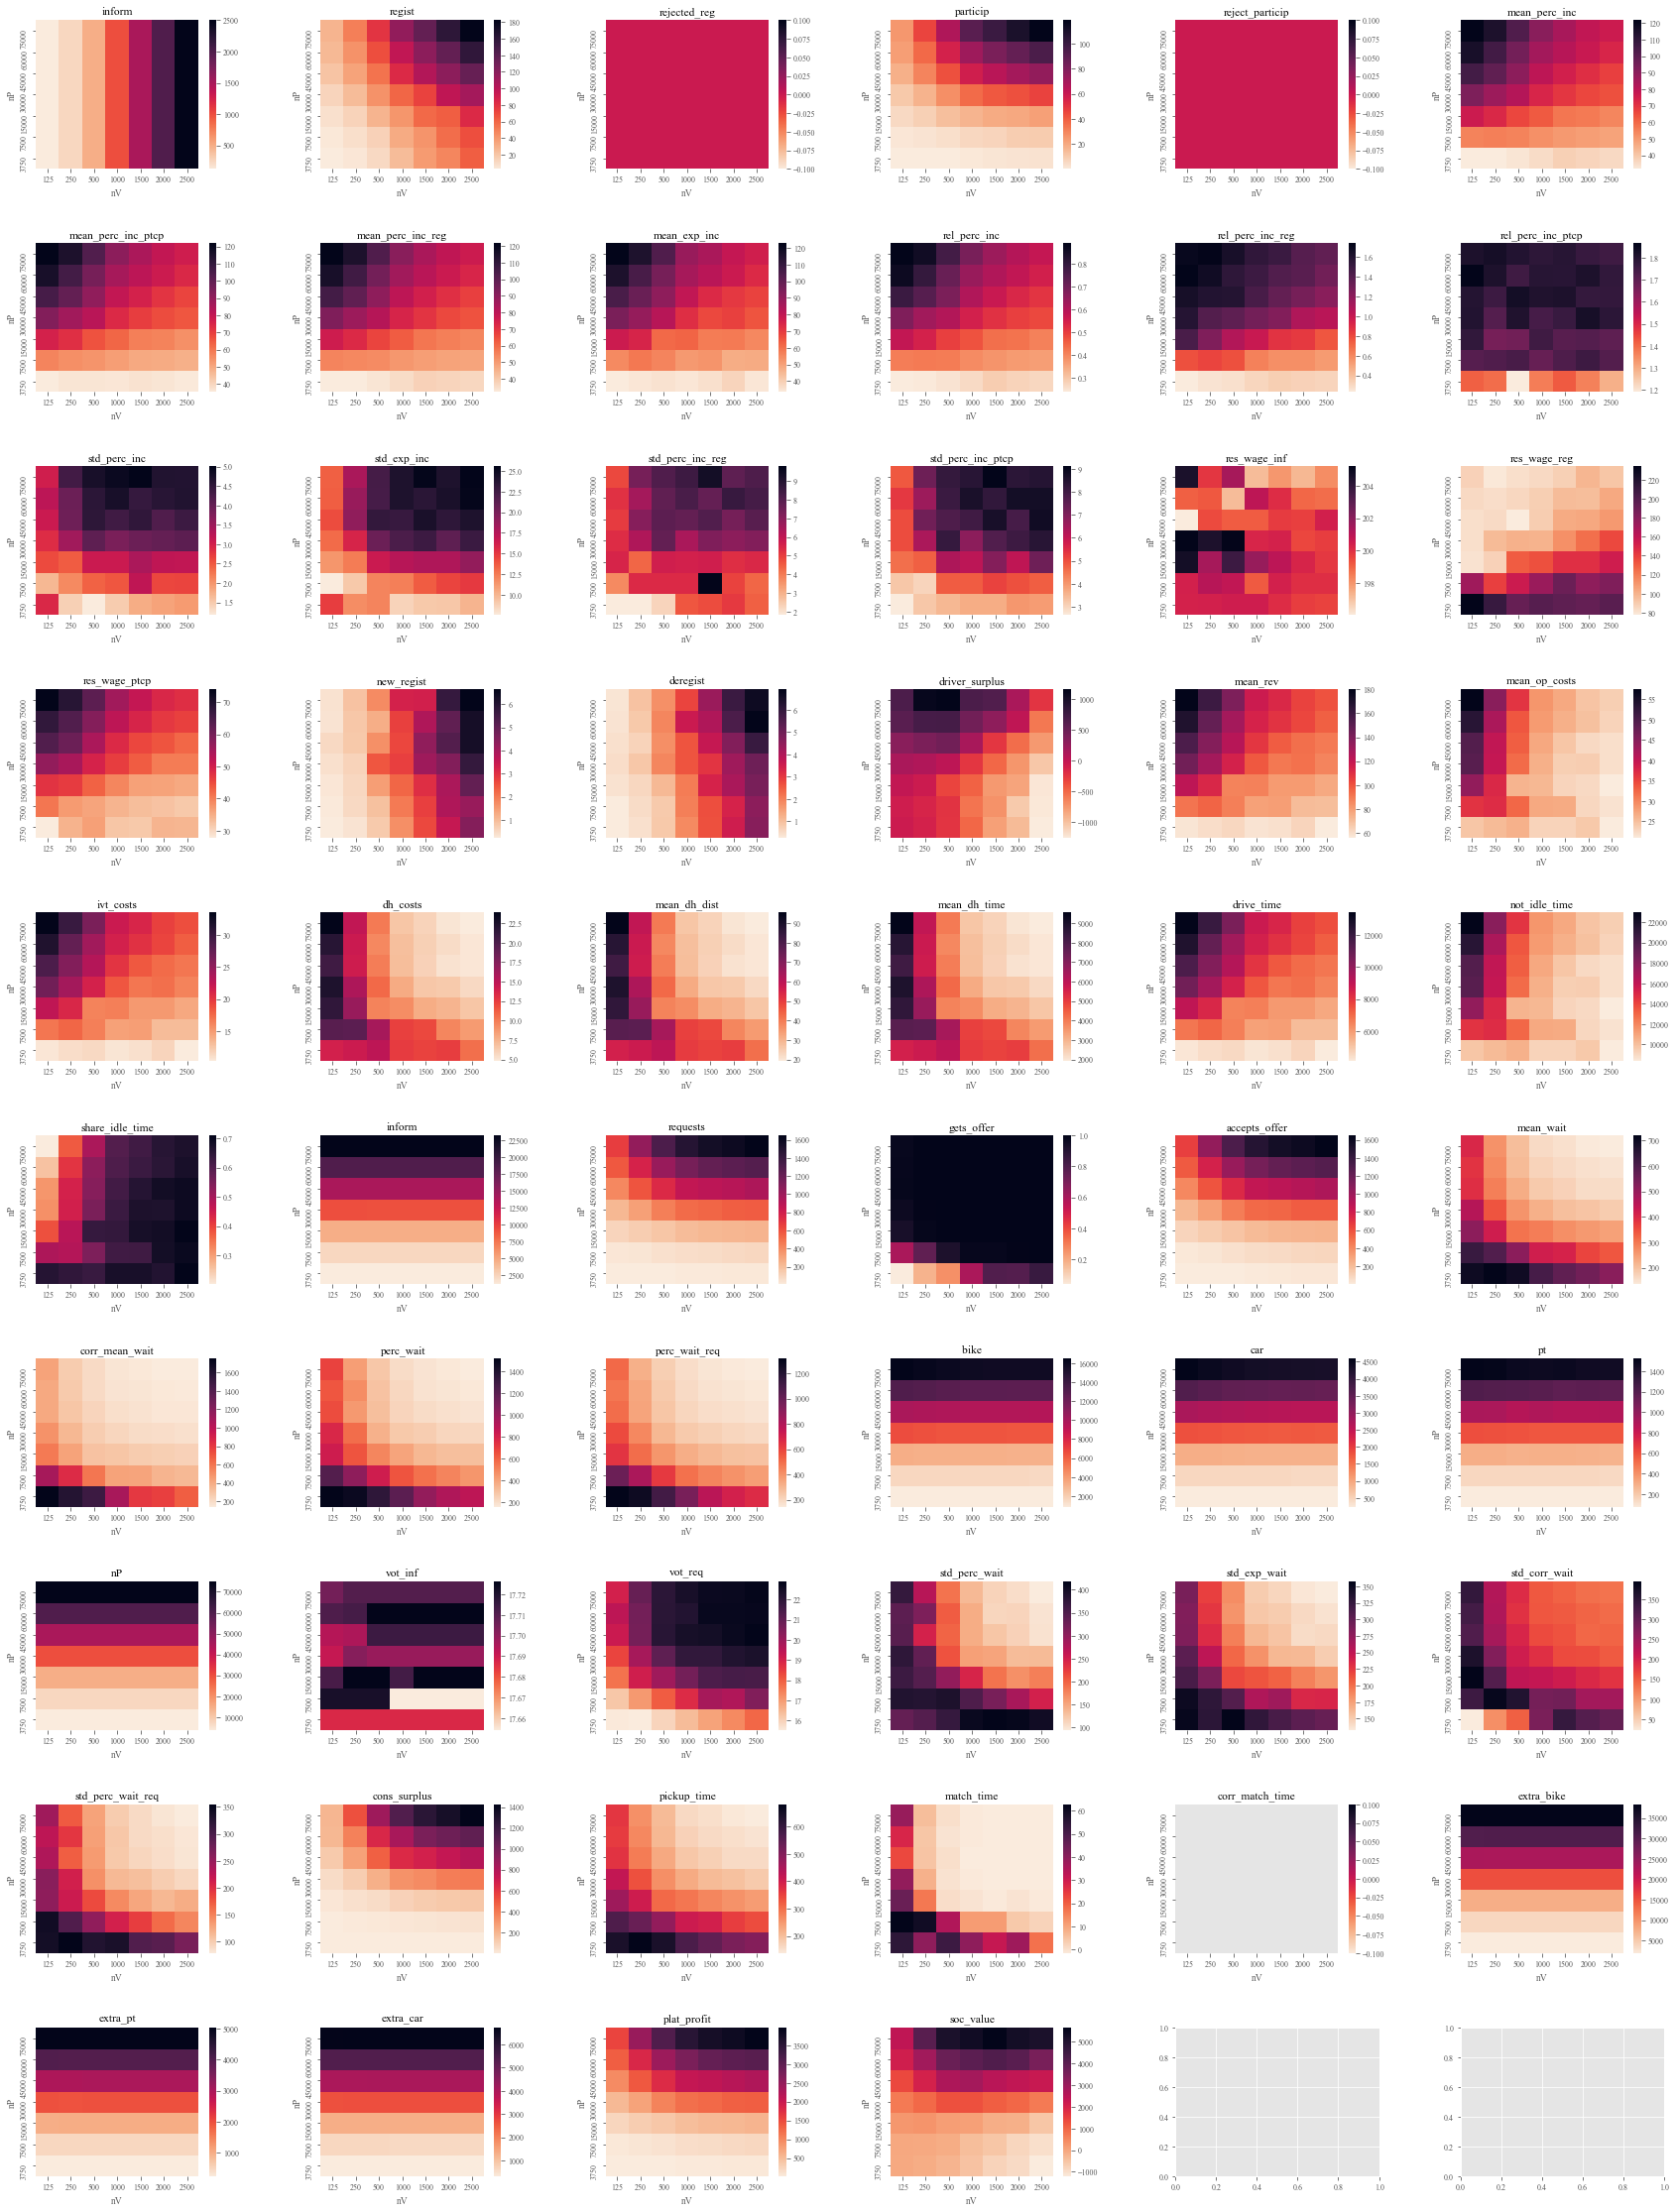

In [20]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(10, 6, figsize = [30,40])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

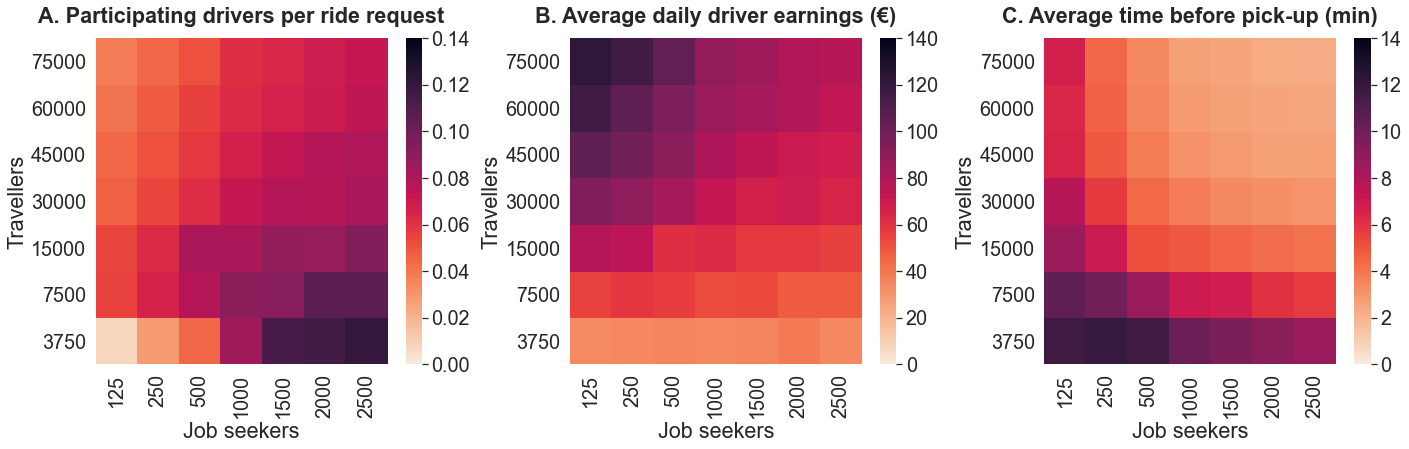

In [23]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 3, figsize = [24,6])
fig.subplots_adjust(hspace=.4, wspace=0.3, left=.12, right=.88)

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=140)
axes[1].set_title('B. Average daily driver earnings (\u20ac)', fontweight="bold", pad=15)
axes[1].invert_yaxis()
axes[1].set_xlabel('Job seekers')
axes[1].set_ylabel('Travellers')

res_proc['wait_time'] = eql_scn.dem.mean_wait / 60
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[2], cmap=cmap, vmin=0, vmax=14)
axes[2].set_title('C. Average time before pick-up (min)', fontweight="bold", pad=15)
axes[2].invert_yaxis()
axes[2].set_xlabel('Job seekers')
axes[2].set_ylabel('Travellers')

res_proc['driv_per_req'] = eql_scn.sup.particip / eql_scn.dem.requests
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='driv_per_req'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.14)
axes[0].set_title('A. Participating drivers per ride request', fontweight="bold", pad=15)
axes[0].invert_yaxis()
axes[0].set_xlabel('Job seekers')
axes[0].set_ylabel('Travellers')

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps_main.jpg'),dpi=300,bbox_inches='tight')

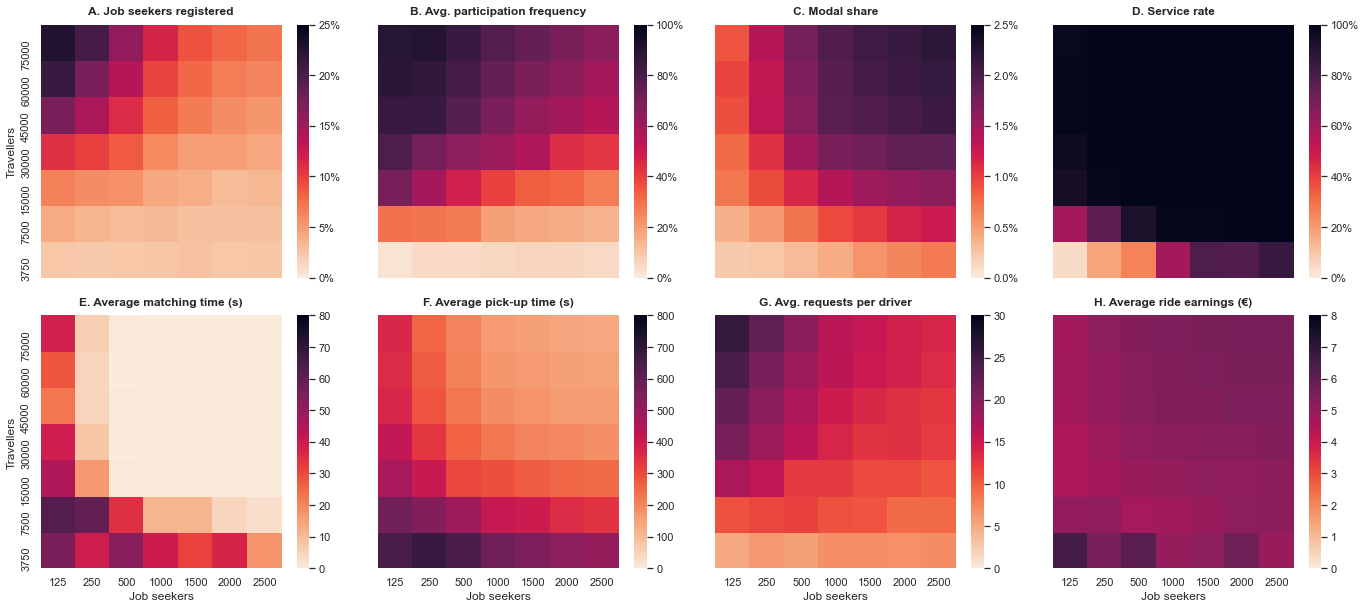

In [24]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(2, 4, figsize = [24,10], sharex=True, sharey=True)
fig.subplots_adjust(hspace=.15, wspace=0.12, left=.12, right=.88)

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,3], cmap=cmap, vmin=0.0, vmax=8.0)
axes[1,3].set_title('H. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[1,3].invert_yaxis()
axes[1,3].set_xlabel('Job seekers')
axes[1,3].set_ylabel('Travellers')
axes[1,3].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=30)
axes[1,2].set_title('G. Avg. requests per driver', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[0,3], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,3].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,3].set_title('D. Service rate', fontweight="bold", pad=10)
axes[0,3].invert_yaxis()
axes[0,3].set_xlabel('Job seekers')
axes[0,3].set_ylabel('Travellers')
axes[0,3].xaxis.label.set_visible(False)
axes[0,3].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=80)
axes[1,0].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=800)
axes[1,1].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].yaxis.label.set_visible(False)

# fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

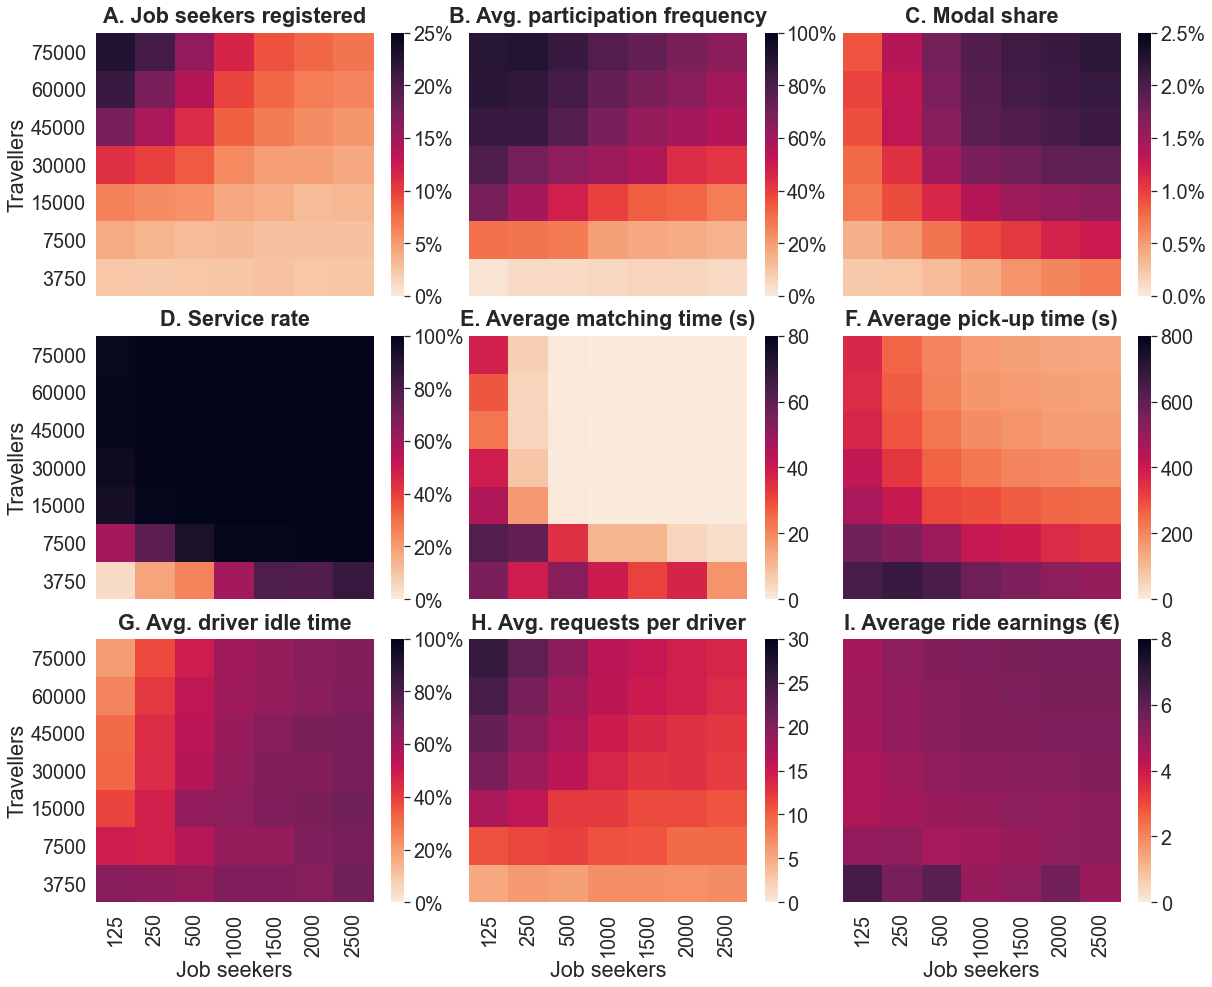

In [25]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0.0, vmax=8.0)
axes[2,2].set_title('I. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Job seekers')
axes[2,2].set_ylabel('Travellers')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=30)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Job seekers')
axes[2,1].set_ylabel('Travellers')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Job seekers')
axes[2,0].set_ylabel('Travellers')

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')
axes[1,0].xaxis.label.set_visible(False)
# axes[1,0].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=80)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=800)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

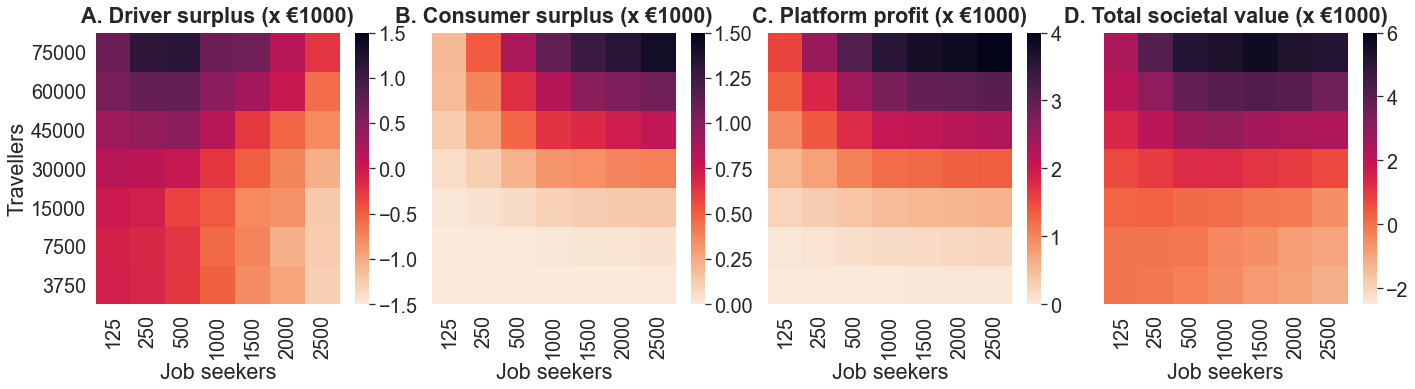

In [27]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,5],sharey=True)
fig.subplots_adjust(hspace=.5, wspace=0.1, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap, vmin=-1.5, vmax=1.5, cbar_kws={"ticks":[-1.5,-1,-0.5,0,0.5,1,1.5]})
axes[0].set_title('A. Driver surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[0].invert_yaxis()
axes[0].set_ylabel('Travellers')
axes[0].set_xlabel('Job seekers')

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap, vmin=0, vmax=1.5)
axes[1].set_title('B. Consumer surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[1].invert_yaxis()
axes[1].set_ylabel('Travellers')
axes[1].set_xlabel('Job seekers')
axes[1].yaxis.label.set_visible(False)

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap, vmin=0, vmax=4)
axes[2].set_title('C. Platform profit (x \u20ac1000)',fontweight="bold", pad=10)
axes[2].invert_yaxis()
axes[2].set_ylabel('Travellers')
axes[2].set_xlabel('Job seekers')
axes[2].yaxis.label.set_visible(False)

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap, vmin=-2.5, vmax=6)
axes[3].set_title('D. Total societal value (x \u20ac1000)',fontweight="bold", pad=10)
axes[3].invert_yaxis()
axes[3].set_ylabel('Travellers')
axes[3].set_xlabel('Job seekers')
axes[3].yaxis.label.set_visible(False)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_soc.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


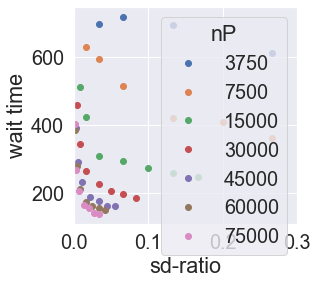

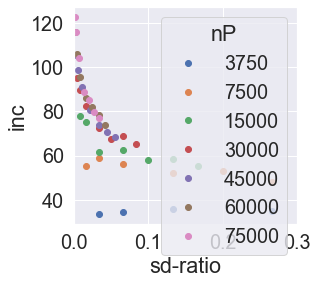

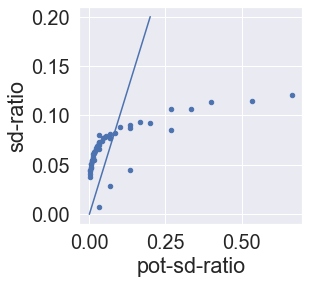

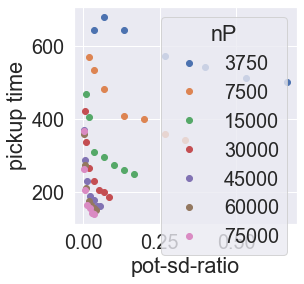

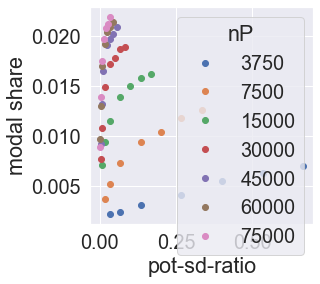

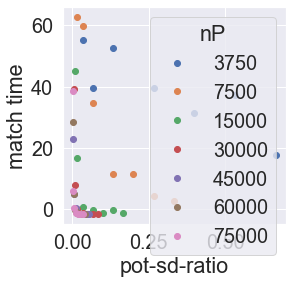

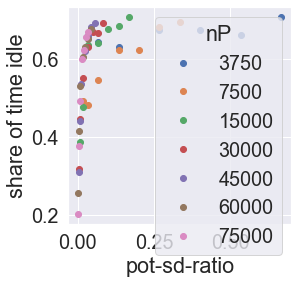

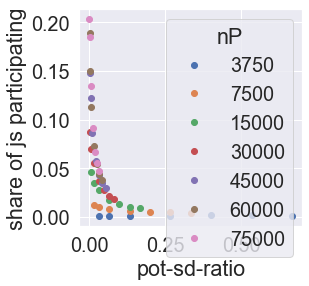

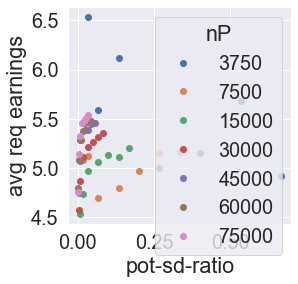

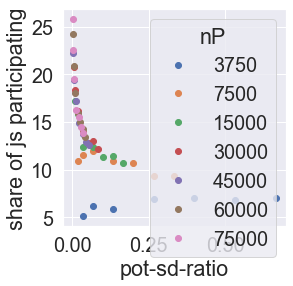

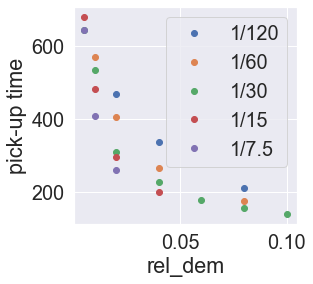

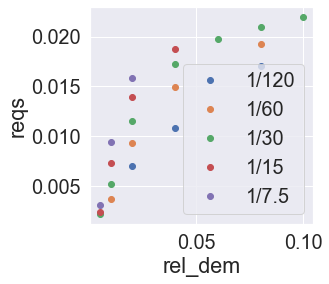

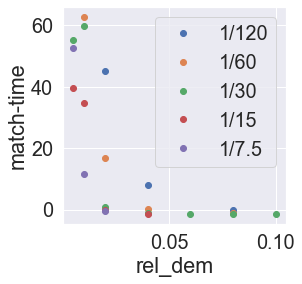

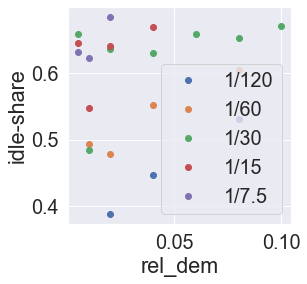

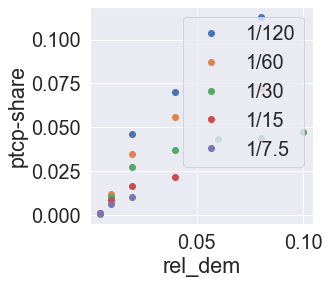

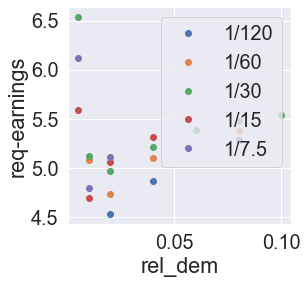

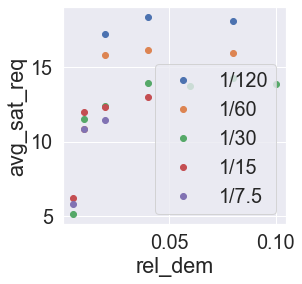

In [28]:
# eql_scn.dem.loc['3750_125']
eql_scn.dem['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
eql_scn.sup['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df = eql_scn.dem.pivot(index='sd-ratio', columns='nP', values='mean_wait')
df2 = eql_scn.sup.pivot(index='sd-ratio', columns='nP', values='mean_exp_inc')
ax = df.plot(ylabel='wait time',marker='o',linestyle='none')
ax2 = df2.plot(ylabel='inc',marker='o',linestyle='none')
ax.set_xlim(0,0.3)
ax2.set_xlim(0,0.3)

df3 = pd.DataFrame()
df3['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df3['sd-ratio'] = eql_scn.sup.particip / eql_scn.dem.requests
ax3 = df3.plot.scatter(x='pot-sd-ratio',y='sd-ratio')
ax3.plot([0,0.2],[0,0.2])

df4 = pd.DataFrame()
df4['nP'] = eql_scn.sup.nP
df4['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df4['pickup-time'] = eql_scn.dem.pickup_time
piv_1 = df4.pivot(index='pot-sd-ratio', columns='nP',values='pickup-time')
ax4 = piv_1.plot(ylabel='pickup time', marker='o',linestyle='none')
df4['reqs'] = eql_scn.dem.requests / eql_scn.sup.nP
piv_2 = df4.pivot(index='pot-sd-ratio', columns='nP',values='reqs')
ax5 = piv_2.plot(ylabel='modal share', marker='o',linestyle='none')
df4['match-time'] = eql_scn.dem.match_time
piv_4 = df4.pivot(index='pot-sd-ratio', columns='nP',values='match-time')
ax7 = piv_4.plot(ylabel='match time', marker='o',linestyle='none')
df4['idle_share'] = eql_scn.sup.share_idle_time
piv_5 = df4.pivot(index='pot-sd-ratio', columns='nP',values='idle_share')
ax8 = piv_5.plot(ylabel='share of time idle', marker='o',linestyle='none')
df4['ptcp_share'] = eql_scn.sup.particip / eql_scn.dem.nV
piv_6 = df4.pivot(index='pot-sd-ratio', columns='nP',values='ptcp_share')
ax9 = piv_6.plot(ylabel='share of js participating', marker='o',linestyle='none')
df4['req_earnings'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
piv_7 = df4.pivot(index='pot-sd-ratio', columns='nP',values='req_earnings')
ax10 = piv_7.plot(ylabel='avg req earnings', marker='o',linestyle='none')
df4['avg_sat_req'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
piv_8 = df4.pivot(index='pot-sd-ratio', columns='nP',values='avg_sat_req')
ax11 = piv_8.plot(ylabel='share of js participating', marker='o',linestyle='none')

df4['nV'] = eql_scn.dem.nV
df4['rel_dem'] = eql_scn.dem.nP / eql_scn.dem.nP.max() / 10
piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='pickup-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax12 = piv_9.plot(ylabel='pick-up time', marker='o', linestyle='none')
ax12.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='reqs')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='reqs', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='match-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='match-time', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='idle_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='idle-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='ptcp_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='ptcp-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='req_earnings')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='req-earnings', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='avg_sat_req')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='avg_sat_req', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

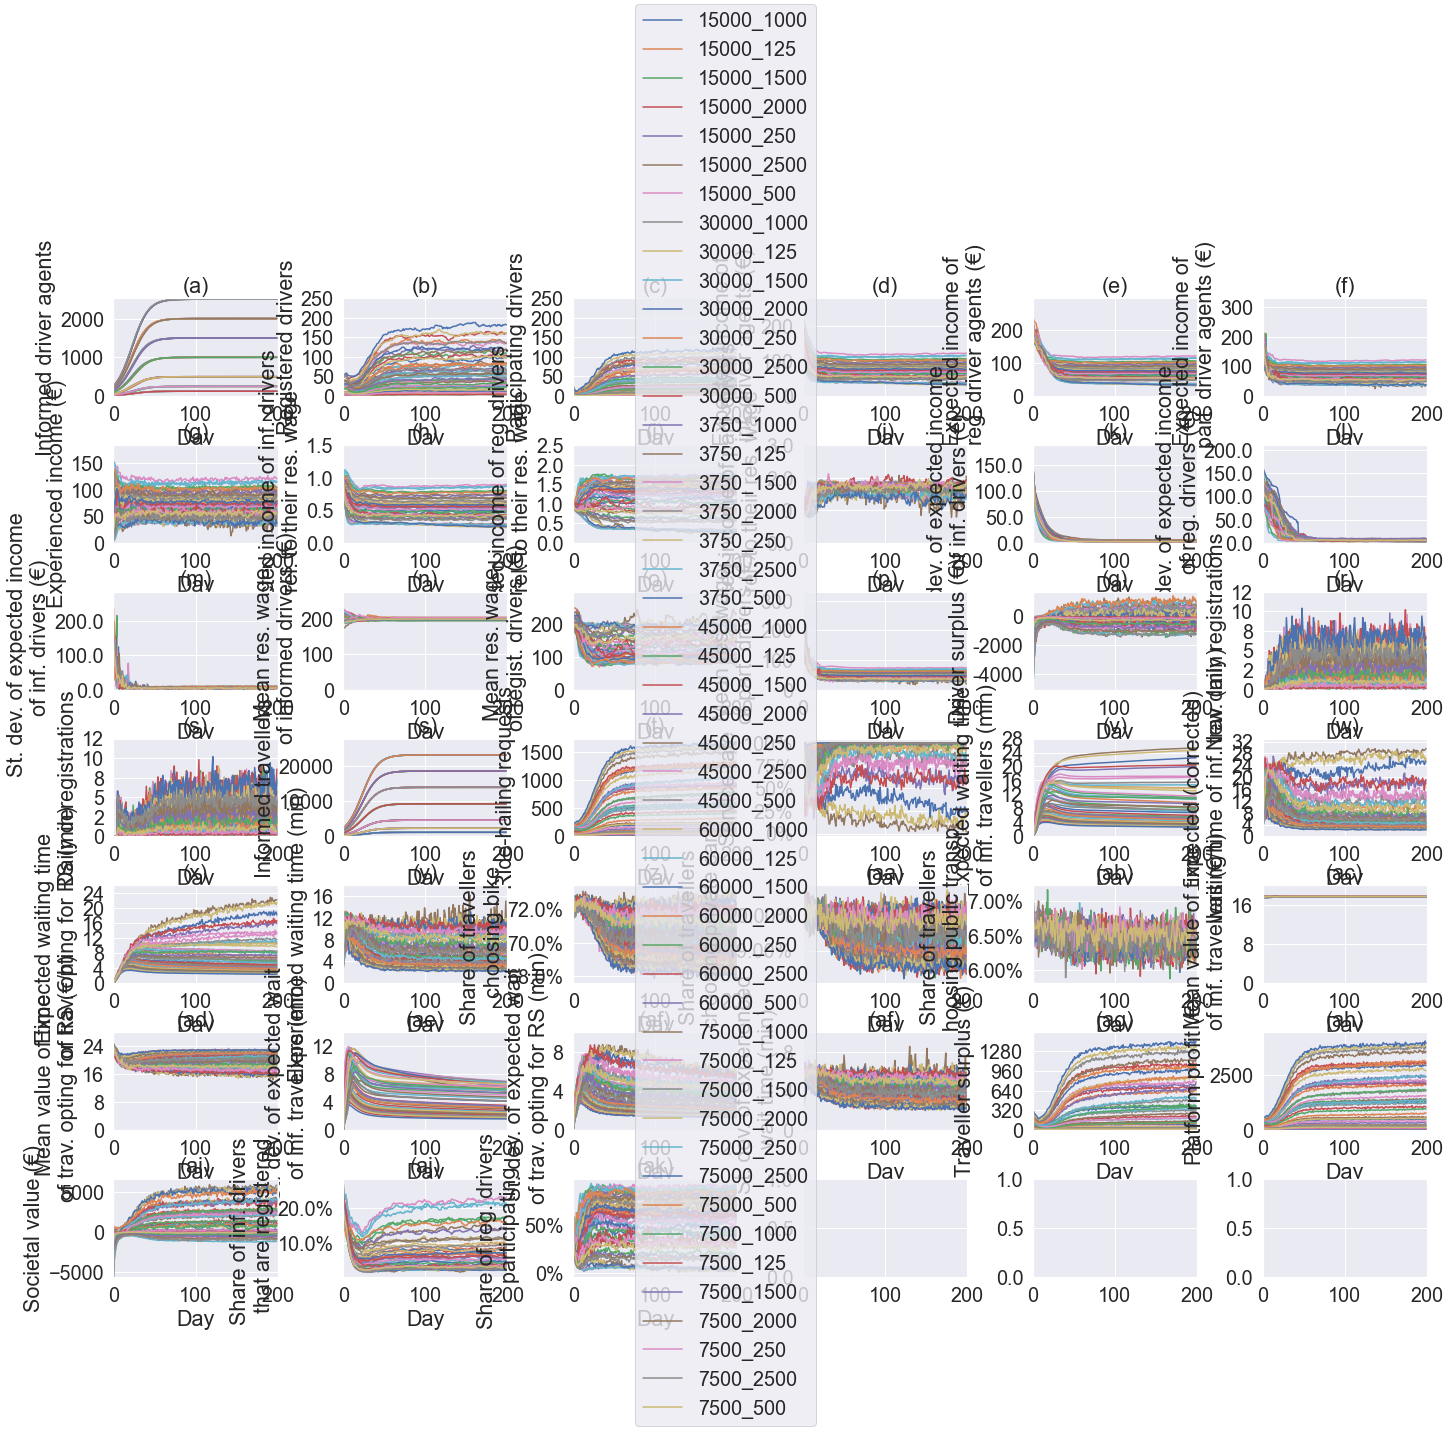

In [29]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

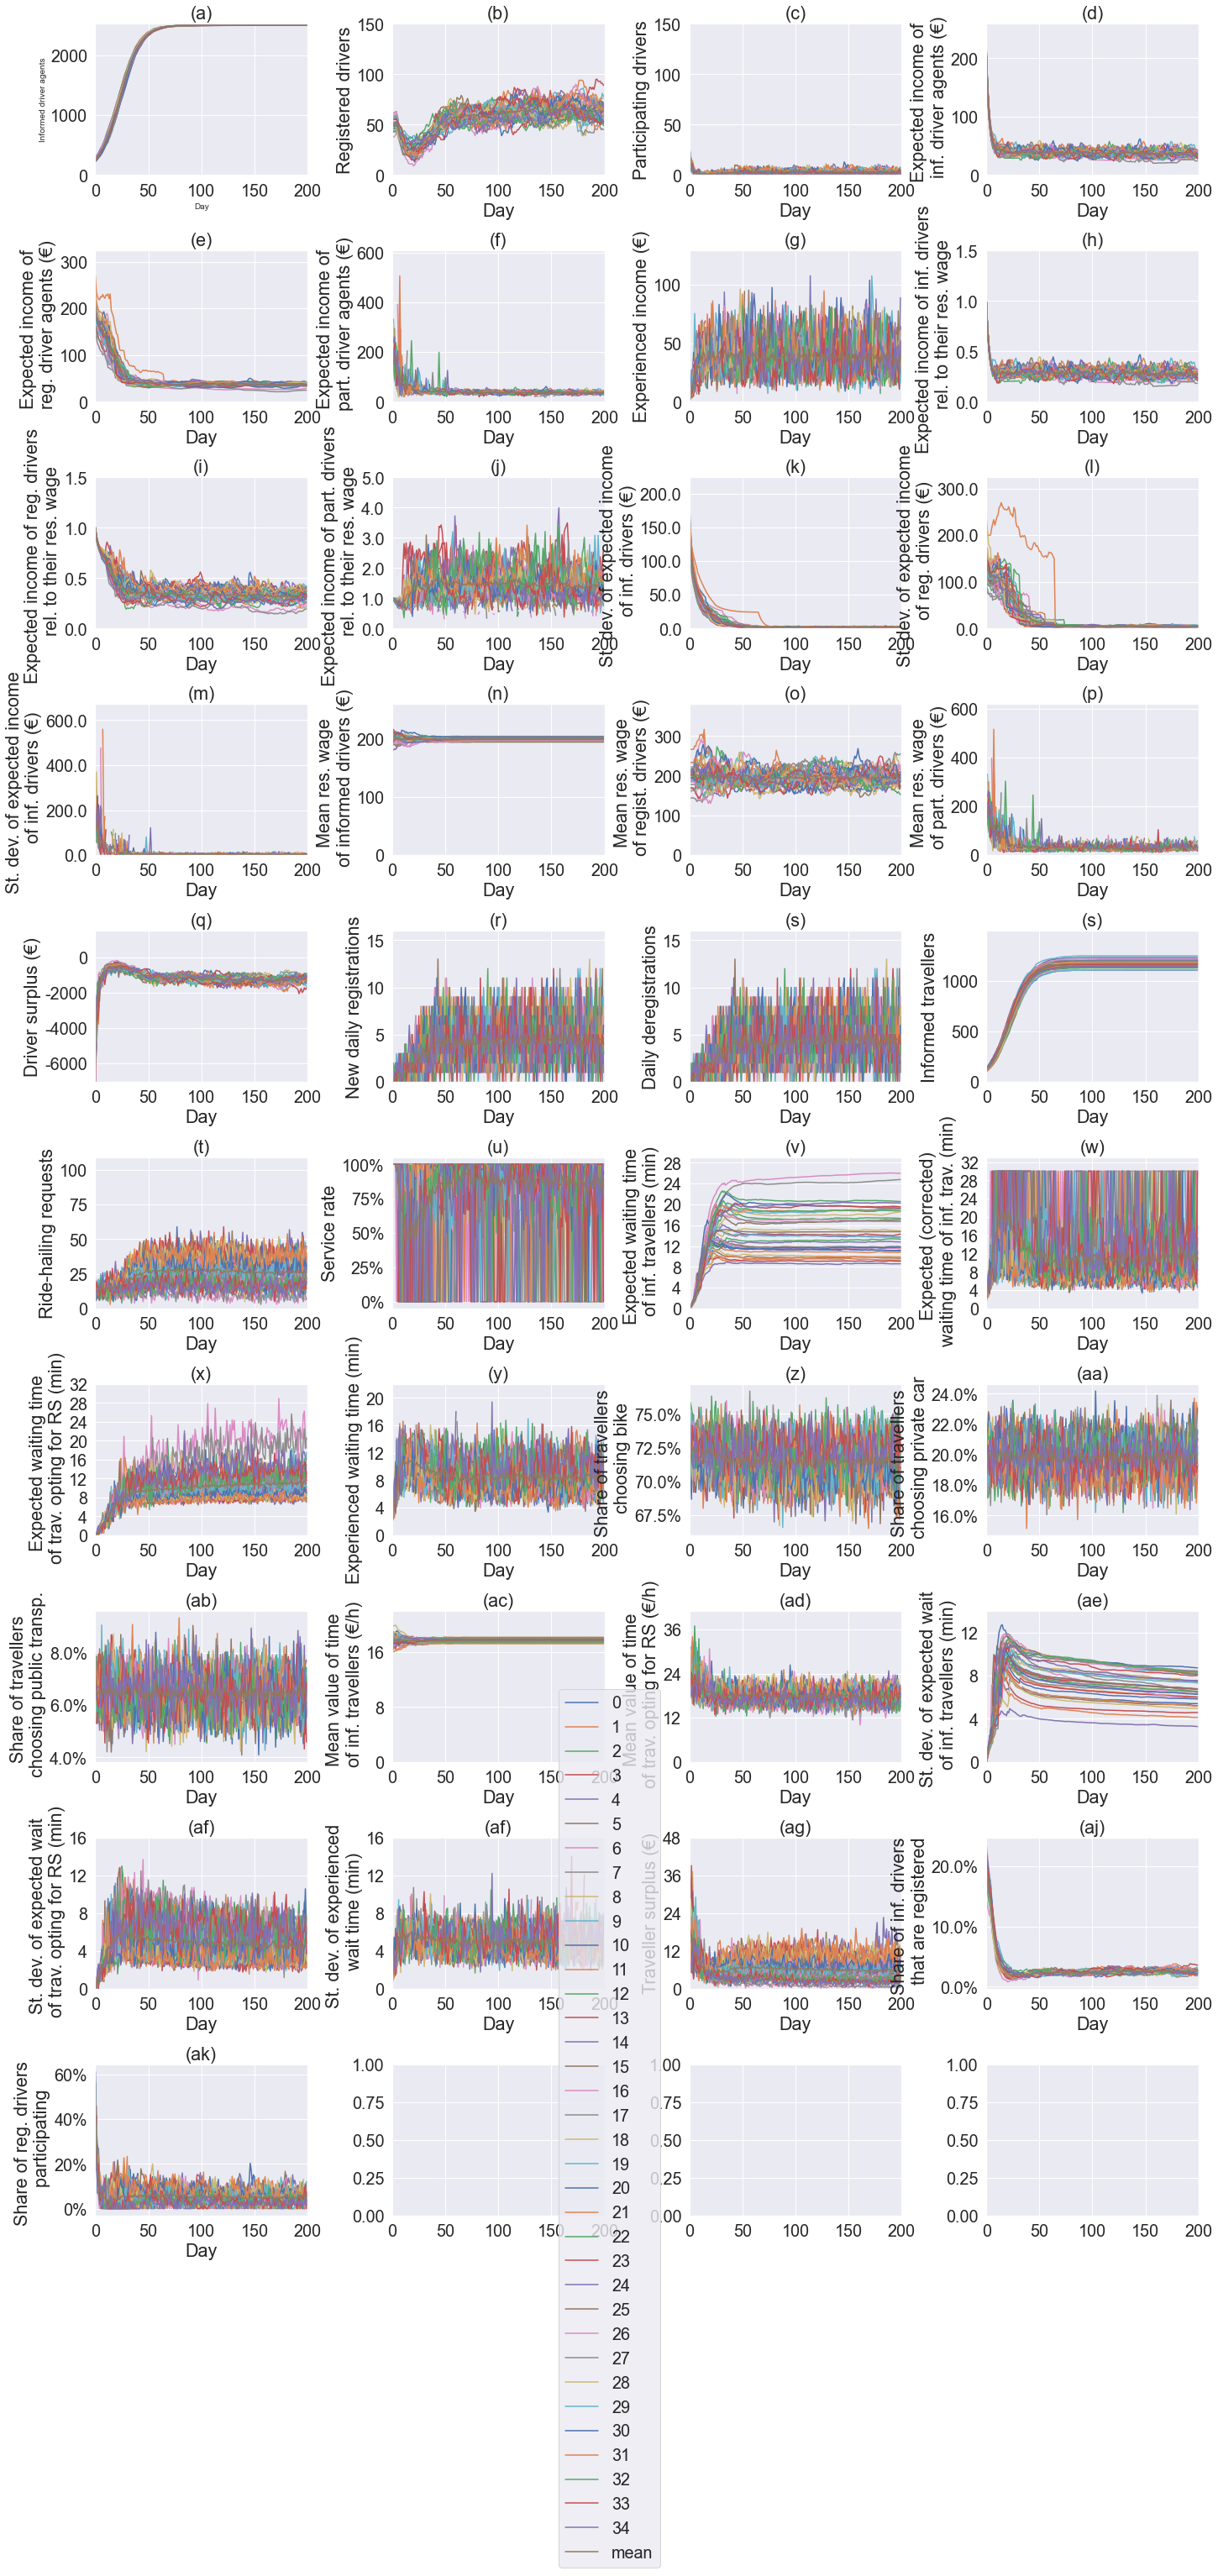

In [30]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '3750_2500'
fig = plot_multi_graph_runs(d2d.sup[scn_name], d2d.dem[scn_name])
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

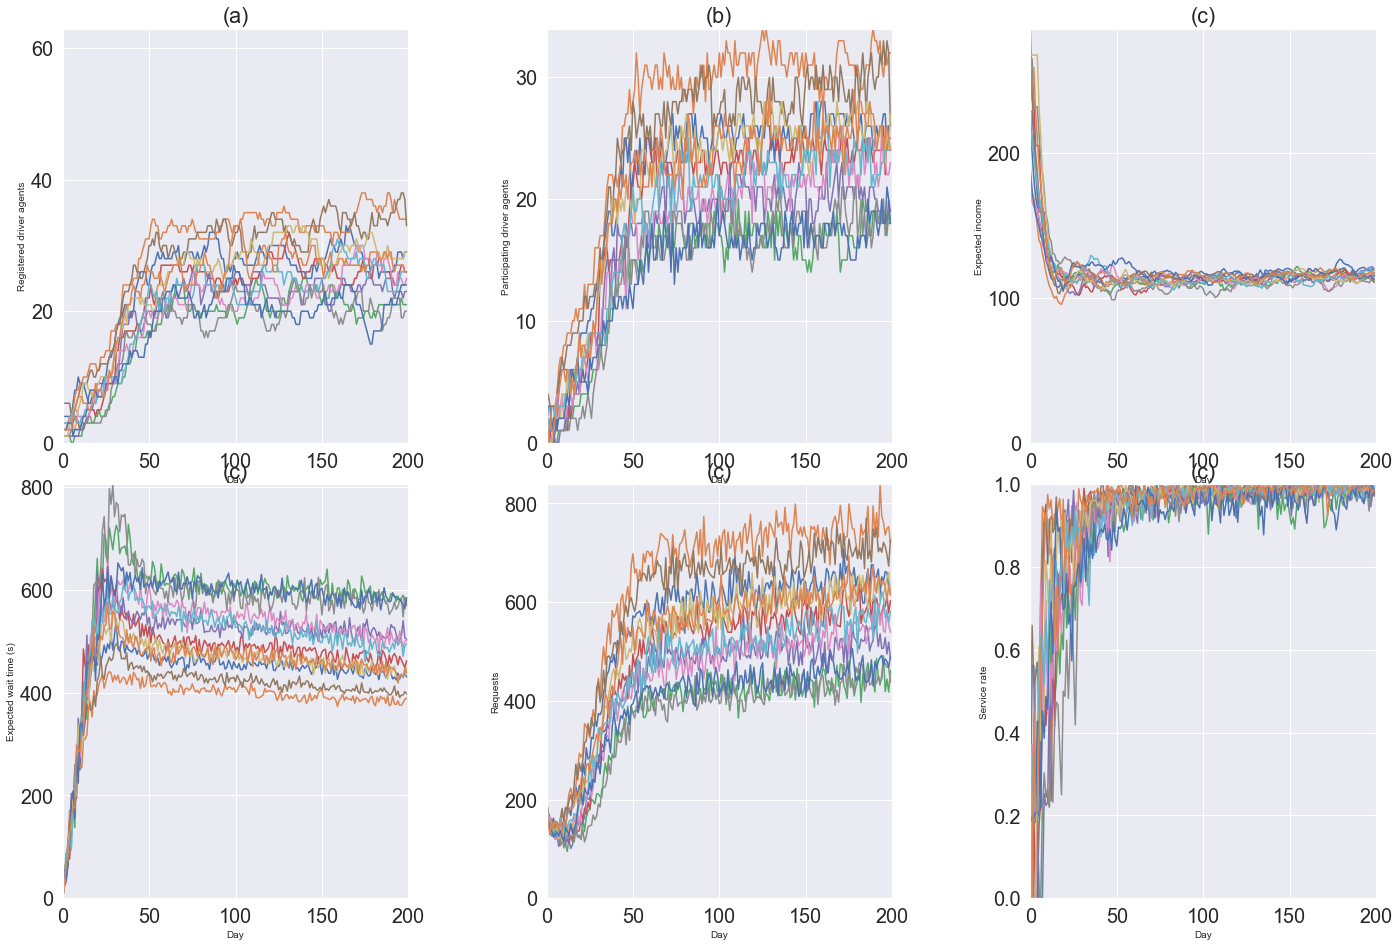

In [34]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '60000_125'
run_ids = d2d.sup[scn_name].inform.drop(['stdev','mean'],axis=1).columns.to_list()
# run_ids = [6,0]
fig, axes = plt.subplots(2, 3, figsize = [24,16])
 # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.1, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,200])

axes[0, 0].plot(d2d.sup[scn_name].regist[run_ids])
axes[0, 0].set_ylabel('Registered driver agents', fontsize = 10)
axes[0, 0].set_xlabel('Day', fontsize = 10)
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = 0, top = d2d.sup[scn_name].regist.max().max() + 25)
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot(d2d.sup[scn_name].particip[run_ids])
axes[0, 1].set_ylabel('Participating driver agents', fontsize = 10)
axes[0, 1].set_xlabel('Day', fontsize = 10)
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = 0, top = d2d.sup[scn_name].particip.max().max())
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(d2d.sup[scn_name].mean_perc_inc[run_ids])
axes[0, 2].set_ylabel('Expected income', fontsize = 10)
axes[0, 2].set_xlabel('Day', fontsize = 10)
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = 0, top = d2d.sup[scn_name].mean_perc_inc.max().max())
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(d2d.dem[scn_name].perc_wait_req[run_ids])
axes[1, 0].set_ylabel('Expected wait time (s)', fontsize = 10)
axes[1, 0].set_xlabel('Day', fontsize = 10)
axes[1, 0].set_title('(c)')
axes[1, 0].set_ylim(bottom = 0, top = d2d.dem[scn_name].perc_wait_req.max().max())
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(d2d.dem[scn_name].requests[run_ids])
axes[1, 1].set_ylabel('Requests', fontsize = 10)
axes[1, 1].set_xlabel('Day', fontsize = 10)
axes[1, 1].set_title('(c)')
axes[1, 1].set_ylim(bottom = 0, top = d2d.dem[scn_name].requests.max().max())
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(d2d.dem[scn_name].gets_offer[run_ids])
axes[1, 2].set_ylabel('Service rate', fontsize = 10)
axes[1, 2].set_xlabel('Day', fontsize = 10)
axes[1, 2].set_title('(c)')
axes[1, 2].set_ylim(bottom = 0, top = d2d.dem[scn_name].gets_offer.max().max())
axes[1, 2].locator_params(axis='y', nbins=5)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_select.jpg'),dpi=300,bbox_inches='tight')

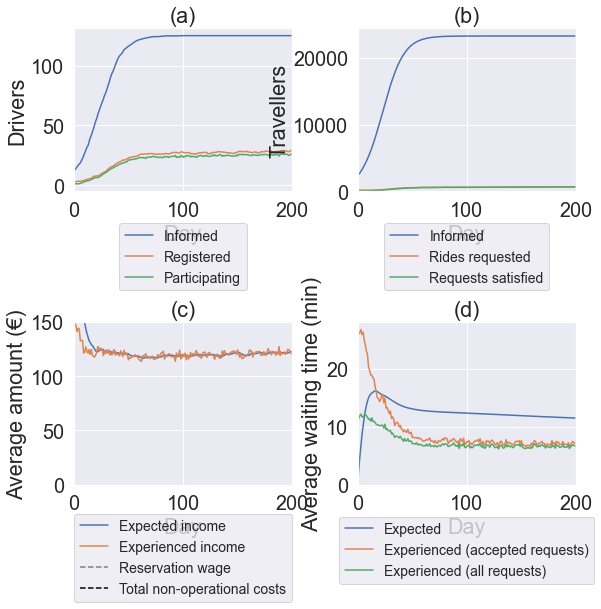

In [36]:
# Plot indicators for single scenario (e.g. base scenario)
value = '75000_125' # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [47]:
eql_stoch = pd.DataFrame(columns = ['ptcp', 'perc_inc', 'req', 'perc_wait'])
for item in vals:
    ind_1 = eql_runs.sup[item].particip.std() / eql_runs.sup[item].particip.mean() 
    ind_2 = eql_runs.sup[item].mean_perc_inc_reg.std() / eql_runs.sup[item].mean_perc_inc_reg.mean()
    ind_3 = eql_runs.dem[item].requests.std() / eql_runs.dem[item].requests.mean()
    ind_4 = eql_runs.dem[item].perc_wait_req.std() / eql_runs.dem[item].perc_wait_req.mean()
    series = pd.Series([ind_1,ind_2,ind_3,ind_4], index = eql_stoch.columns)
    eql_stoch = eql_stoch.append(series, ignore_index=True)
eql_stoch['scn'] = vals
eql_stoch.set_index('scn', inplace = True)
eql_stoch.head(5)

,ptcp,perc_inc,req,perc_wait
scn,,,,
15000_1000,0.073312,0.014121,0.079020,0.066459
15000_125,0.271253,0.066916,0.186723,0.137257
15000_1500,0.055065,0.037300,0.038108,0.028750
15000_2000,0.060318,0.040402,0.055989,0.020455
15000_250,0.142030,0.055938,0.115009,0.085442


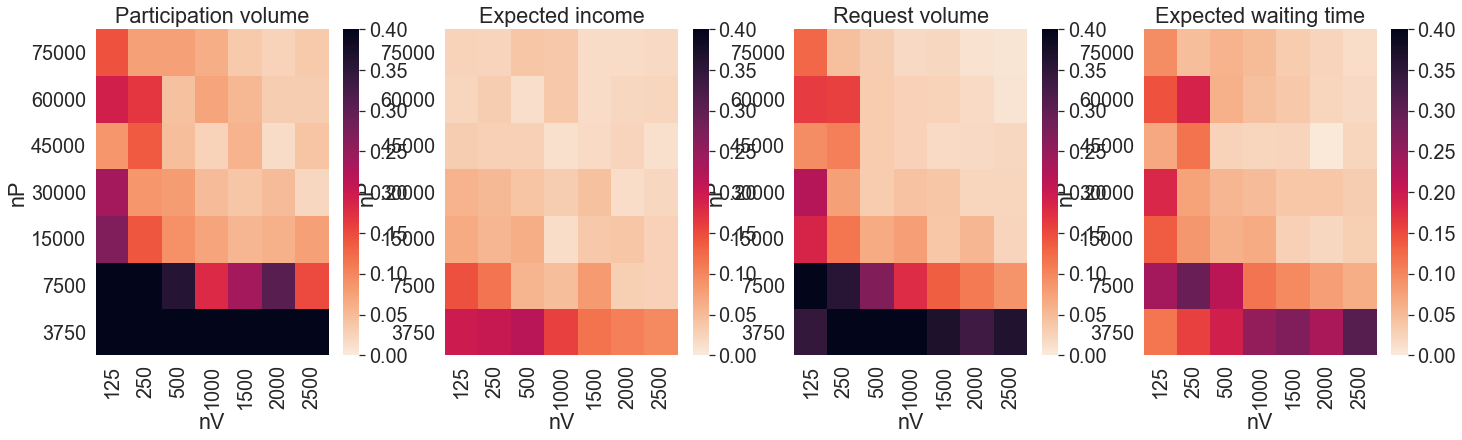

In [48]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,6])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_stoch.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['ptcp'] = eql_stoch.ptcp.copy()
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.4)
axes[0].set_title('Participation volume')
axes[0].invert_yaxis()

res_proc['perc_inc'] = eql_stoch.perc_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=0.4)
axes[1].set_title('Expected income')
axes[1].invert_yaxis()

res_proc['req'] = eql_stoch.req.copy()
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req'), ax = axes[2], cmap=cmap, vmin=0, vmax=0.4)
axes[2].set_title('Request volume')
axes[2].invert_yaxis()

res_proc['perc_wait'] = eql_stoch.perc_wait.copy()
axes[3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_wait'), ax = axes[3], cmap=cmap, vmin=0, vmax=0.4)
axes[3].set_title('Expected waiting time')
axes[3].invert_yaxis()

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], '{}-{}_market-size-stochasticity.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')